<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Low_Temperature_Capacitance_Comparison_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2025)

Open Access (CC-BY-4.0)

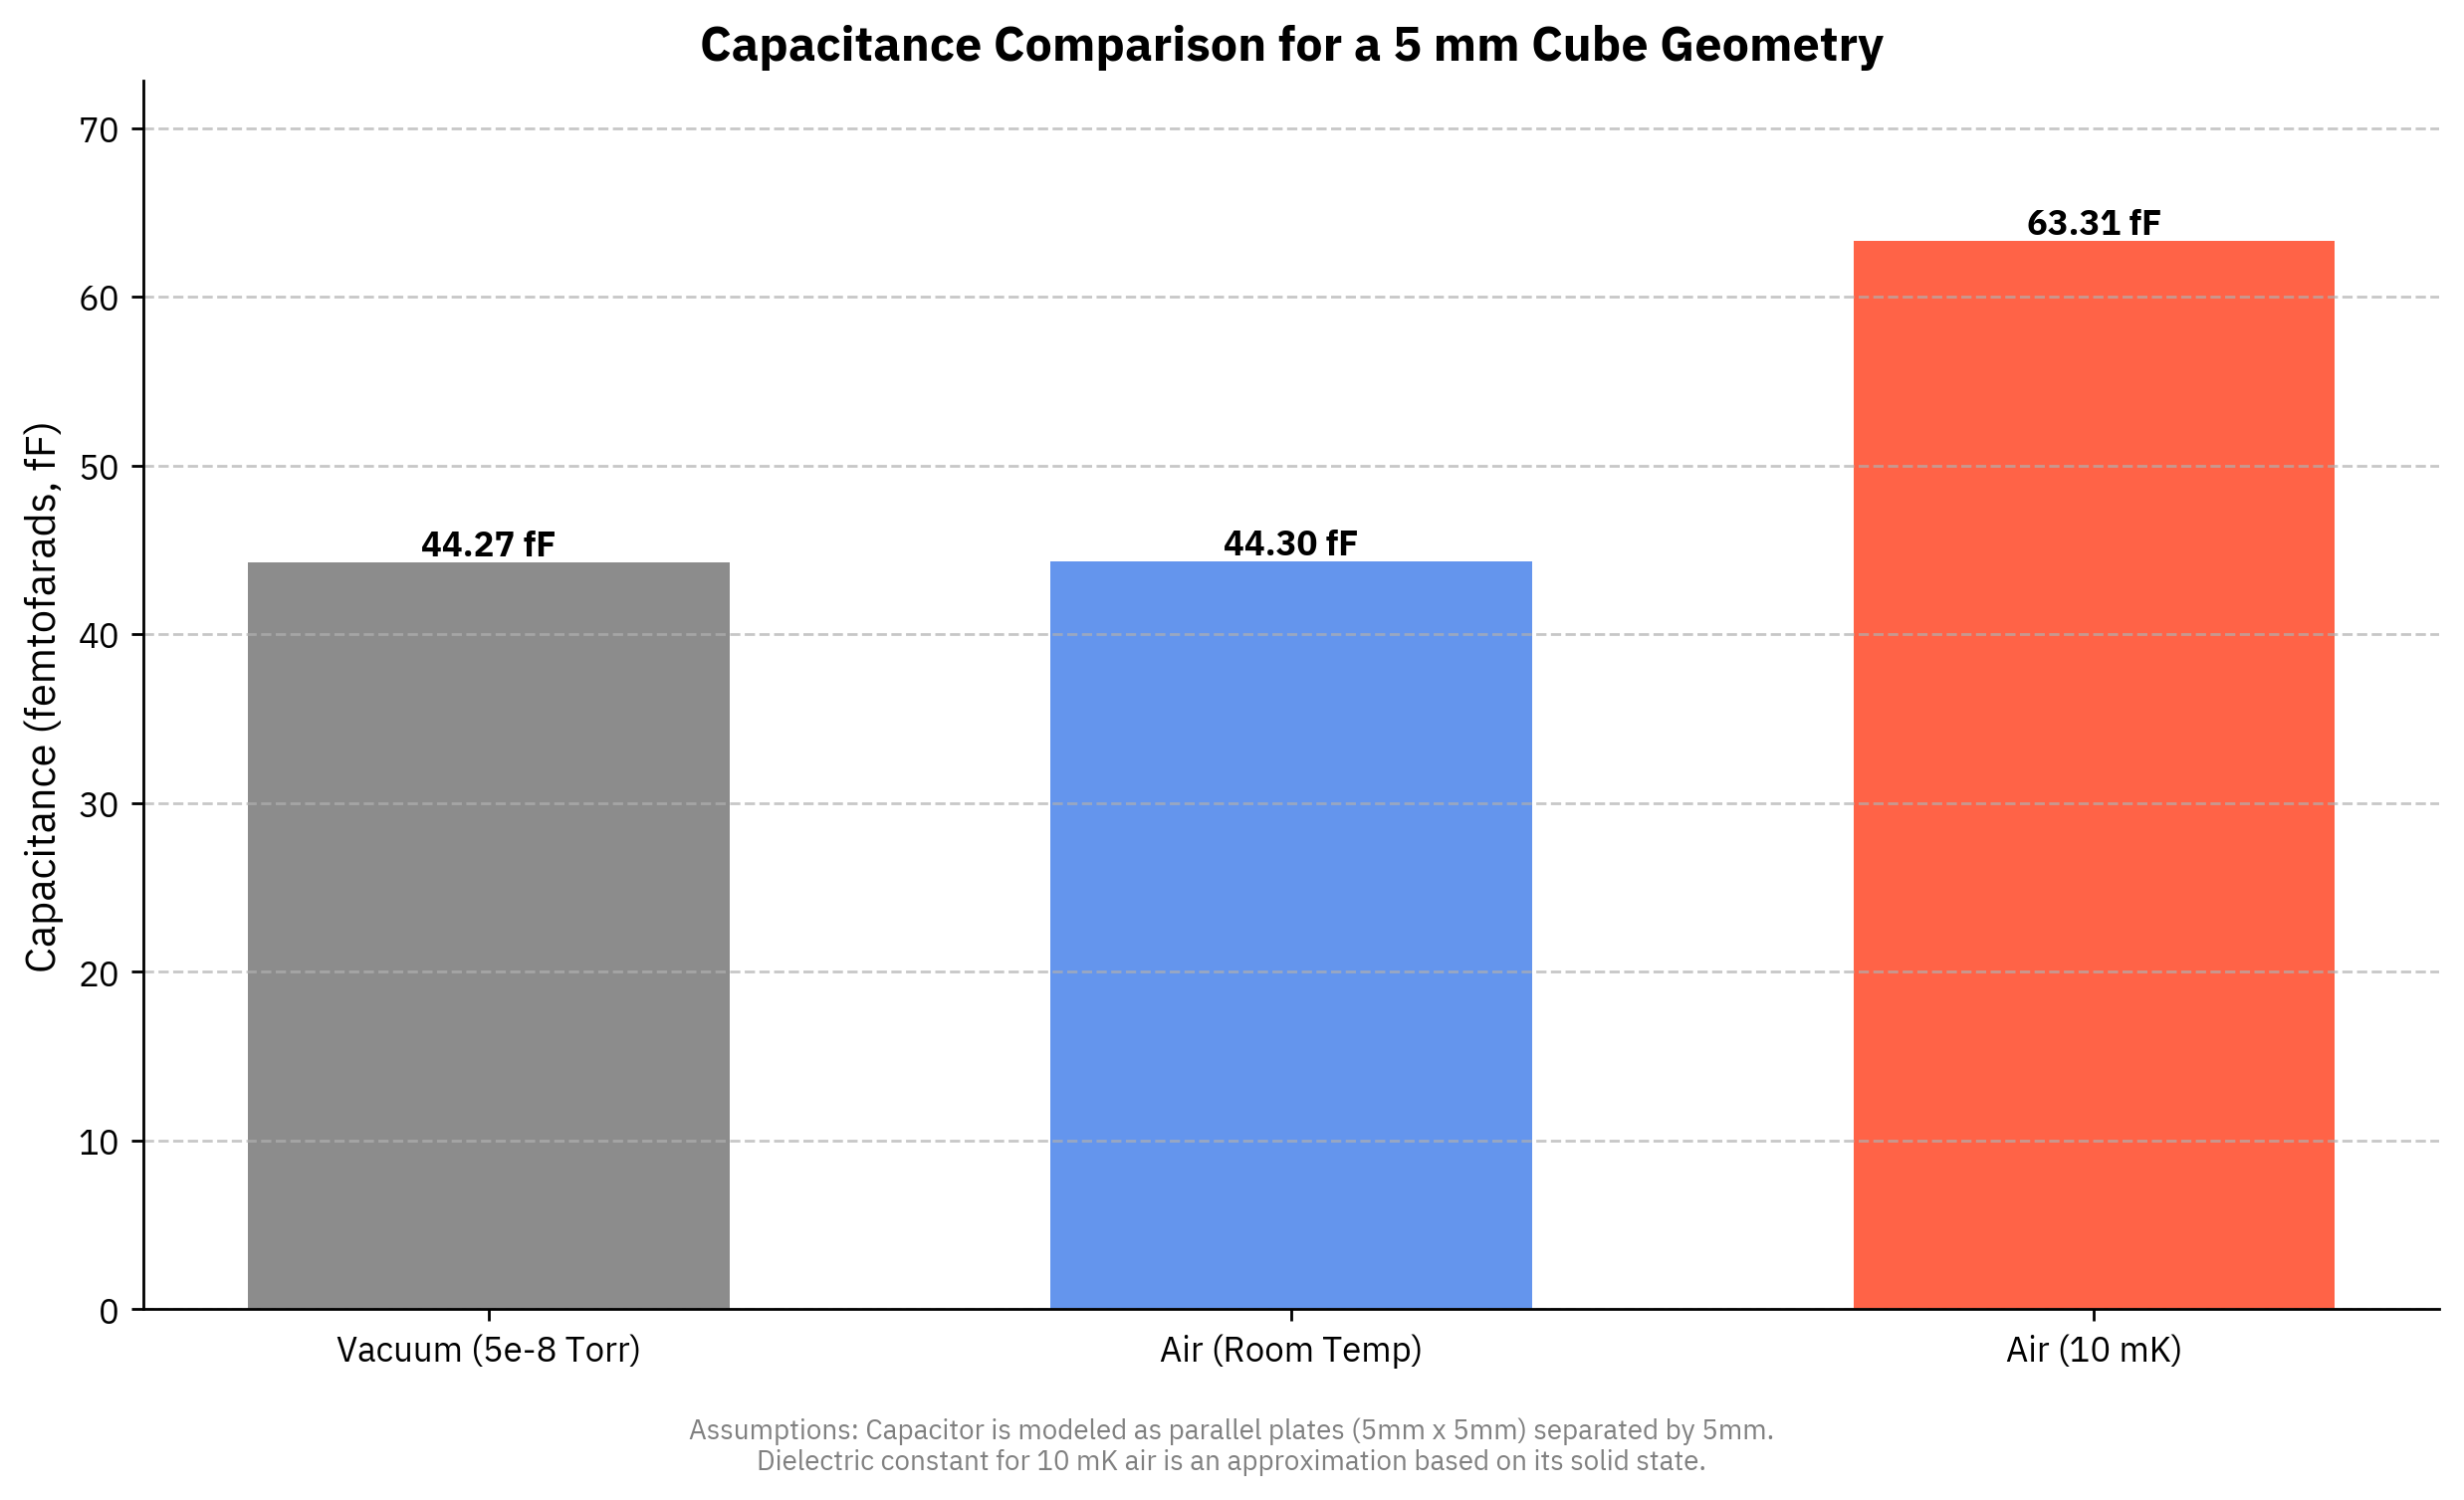

In [4]:
"""
Capacitance Visualization Module

This script models and visualizes the capacitance of a specific cubic volume
across various dielectric conditions.
"""

# Ensure required dependencies are present.
# !pip install matplotlib numpy

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ==========================================
# 1. Control Knobs & Global Parameters
# ==========================================

# Global resolution setting.
PLOT_RESOLUTION_DPI = 250

# Desired typeface for all rendered text elements.
TARGET_FONT_FAMILY = 'IBM Plex Sans'

# Physical parameters for the volume geometry.
CUBE_SIDE_LENGTH_METERS = 5e-3
CAPACITOR_AREA_SQ_METERS = CUBE_SIDE_LENGTH_METERS ** 2
CAPACITOR_DISTANCE_METERS = CUBE_SIDE_LENGTH_METERS

# The permittivity of free space in Farads per meter (F/m).
PERMITTIVITY_FREE_SPACE = 8.854e-12

# A dictionary mapping precise physical states to their relative permittivity values.
# Vacuum pressure is given in Torr.
DIELECTRIC_CONSTANTS = {
    'Vacuum (5e-8 Torr)': 1.0,
    'Air (Room Temp)': 1.00058,
    'Air (10 mK)': 1.43
}

# Updated TrueType Font (TTF) binary locations reflecting the current IBM Plex repository structure.
FONT_RESOURCE_URLS = {
    "IBMPlexSans-Regular.ttf": "https://raw.githubusercontent.com/IBM/plex/master/packages/plex-sans/fonts/complete/ttf/IBMPlexSans-Regular.ttf",
    "IBMPlexSans-Bold.ttf": "https://raw.githubusercontent.com/IBM/plex/master/packages/plex-sans/fonts/complete/ttf/IBMPlexSans-Bold.ttf"
}

# ==========================================
# 2. Font Integration & Configuration
# ==========================================

def configure_matplotlib_typography() -> None:
    """
    Retrieves the TrueType Font binaries from the updated remote repository and
    configures Matplotlib to utilize the specified custom typeface globally.
    """
    for filename, url in FONT_RESOURCE_URLS.items():
        if not os.path.exists(filename):
            urllib.request.urlretrieve(url, filename)
        fm.fontManager.addfont(filename)

    plt.rcParams['font.family'] = TARGET_FONT_FAMILY
    plt.rcParams['figure.dpi'] = PLOT_RESOLUTION_DPI

# ==========================================
# 3. Capacitance Calculation
# ==========================================

def compute_capacitance_values() -> dict:
    """
    Computes the capacitance in femtofarads (fF) for each defined dielectric condition.

    Returns:
        A dictionary containing the conditions as keys and capacitance in fF as values.
    """
    calculated_capacitances_ff = {}
    for condition_name, relative_permittivity in DIELECTRIC_CONSTANTS.items():
        # Calculate absolute capacitance in Farads (F)
        capacitance_farads = relative_permittivity * (PERMITTIVITY_FREE_SPACE * CAPACITOR_AREA_SQ_METERS / CAPACITOR_DISTANCE_METERS)
        # Convert the resulting Farads to femtofarads (fF) for enhanced readability
        capacitance_femtofarads = capacitance_farads * 1e15
        calculated_capacitances_ff[condition_name] = capacitance_femtofarads

    return calculated_capacitances_ff

# ==========================================
# 4. Plot Generation
# ==========================================

def render_capacitance_chart() -> None:
    """
    Generates and displays the inline bar chart utilizing the computed capacitance
    data alongside the specialized typography and resolution settings.
    """
    configure_matplotlib_typography()
    data_mapping = compute_capacitance_values()

    labels = list(data_mapping.keys())
    values = list(data_mapping.values())

    figure, axes = plt.subplots(figsize=(10, 6))

    # Hexadecimal color codes for distinct visual categorization
    bar_colors = ['#8c8c8c', '#6495ed', '#ff6347']
    bars = axes.bar(labels, values, color=bar_colors, width=0.6)

    for bar in bars:
        height = bar.get_height()
        axes.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f'{height:.2f} fF',
            va='bottom',
            ha='center',
            fontweight='bold'
        )

    axes.set_ylabel('Capacitance (femtofarads, fF)', fontsize=12)
    axes.set_title('Capacitance Comparison for a 5 mm Cube Geometry', fontsize=14, fontweight='bold')
    axes.set_ylim(0, max(values) * 1.15)
    axes.grid(axis='y', linestyle='--', alpha=0.7)

    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

    plt.figtext(
        0.5, 0.01,
        'Assumptions: Capacitor is modeled as parallel plates (5mm x 5mm) separated by 5mm.\n'
        'Dielectric constant for 10 mK air is an approximation based on its solid state.',
        wrap=True, ha='center', fontsize=8, style='italic', color='gray'
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    # The plot is displayed directly within the Colaboratory notebook without saving to disk.
    plt.show()

if __name__ == '__main__':
    render_capacitance_chart()